# Сравнение четырёхмикрофонных решёток

Карты условной угловой CRLB, ранга матрицы Фишера, числа обусловленности и областей локального вырождения. Все решётки имеют максимальную апертуру $D=0.20$ м; используются $M-1$ линейно независимых TDOA относительно микрофона 0 и абстрактная модель независимых измерений с $\sigma_{\mathrm{tdoa}}=50$ мкс.

CRLB относится к согласованной гауссовской модели уже оценённых TDOA. Плоские решётки сохраняют зеркальную неоднозначность относительно плоскости $xy$, даже если локальная CRLB конечна.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

project_root = Path.cwd()
if not (project_root / 'model').is_dir():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from model.geometry import aperture, comparison_arrays, geometry_rank, reference_pairs
from model.jacobian import far_field_tdoa_jacobian
from model.statistics import (
    DEFAULT_SIGMA_TDOA,
    conditional_angular_crlb,
    conditional_crlb,
    fisher_information,
    matrix_diagnostics,
)

D = 0.20
arrays = comparison_arrays(D)
[(name, positions.shape[0], geometry_rank(positions), aperture(positions)) for name, positions in arrays.items()]

[('linear', 4, 1, 0.2),
 ('L-shaped', 4, 2, 0.2),
 ('rectangle 3:1', 4, 2, 0.19999999999999998),
 ('square', 4, 2, 0.2),
 ('tetrahedral', 4, 3, 0.2)]

## Расчёт сетки

Ранг определяется с относительным порогом $10^{-10}$. Для вырожденных точек CRLB не вычисляется и остаётся `NaN`; число обусловленности отображается как $\log_{10}\kappa$ с насыщением на 16.

In [2]:
azimuth_degrees = np.linspace(0.0, 360.0, 73)
elevation_degrees = np.linspace(0.0, 60.0, 31)
azimuth_radians = np.deg2rad(azimuth_degrees)
elevation_radians = np.deg2rad(elevation_degrees)
results = {}

for name, positions in arrays.items():
    shape = (len(elevation_radians), len(azimuth_radians))
    rank_map = np.zeros(shape, dtype=int)
    condition_map = np.full(shape, np.inf)
    crlb_map = np.full(shape, np.nan)
    pairs = reference_pairs(len(positions))
    for elevation_index, elevation in enumerate(elevation_radians):
        for azimuth_index, phi in enumerate(azimuth_radians):
            jacobian = far_field_tdoa_jacobian(phi, elevation, positions, pairs)
            information = fisher_information(jacobian, sigma_tdoa=DEFAULT_SIGMA_TDOA)
            diagnostics = matrix_diagnostics(information)
            rank_map[elevation_index, azimuth_index] = diagnostics.rank
            condition_map[elevation_index, azimuth_index] = diagnostics.condition_number
            if not diagnostics.is_degenerate:
                angular_bound = conditional_angular_crlb(information, elevation)
                crlb_map[elevation_index, azimuth_index] = angular_bound.angular_rms_deg
    results[name] = {
        'rank': rank_map,
        'condition': condition_map,
        'crlb_deg': crlb_map,
        'degenerate': rank_map < 2,
    }

len(arrays) * len(elevation_radians) * len(azimuth_radians)

11315

## Карты чувствительности

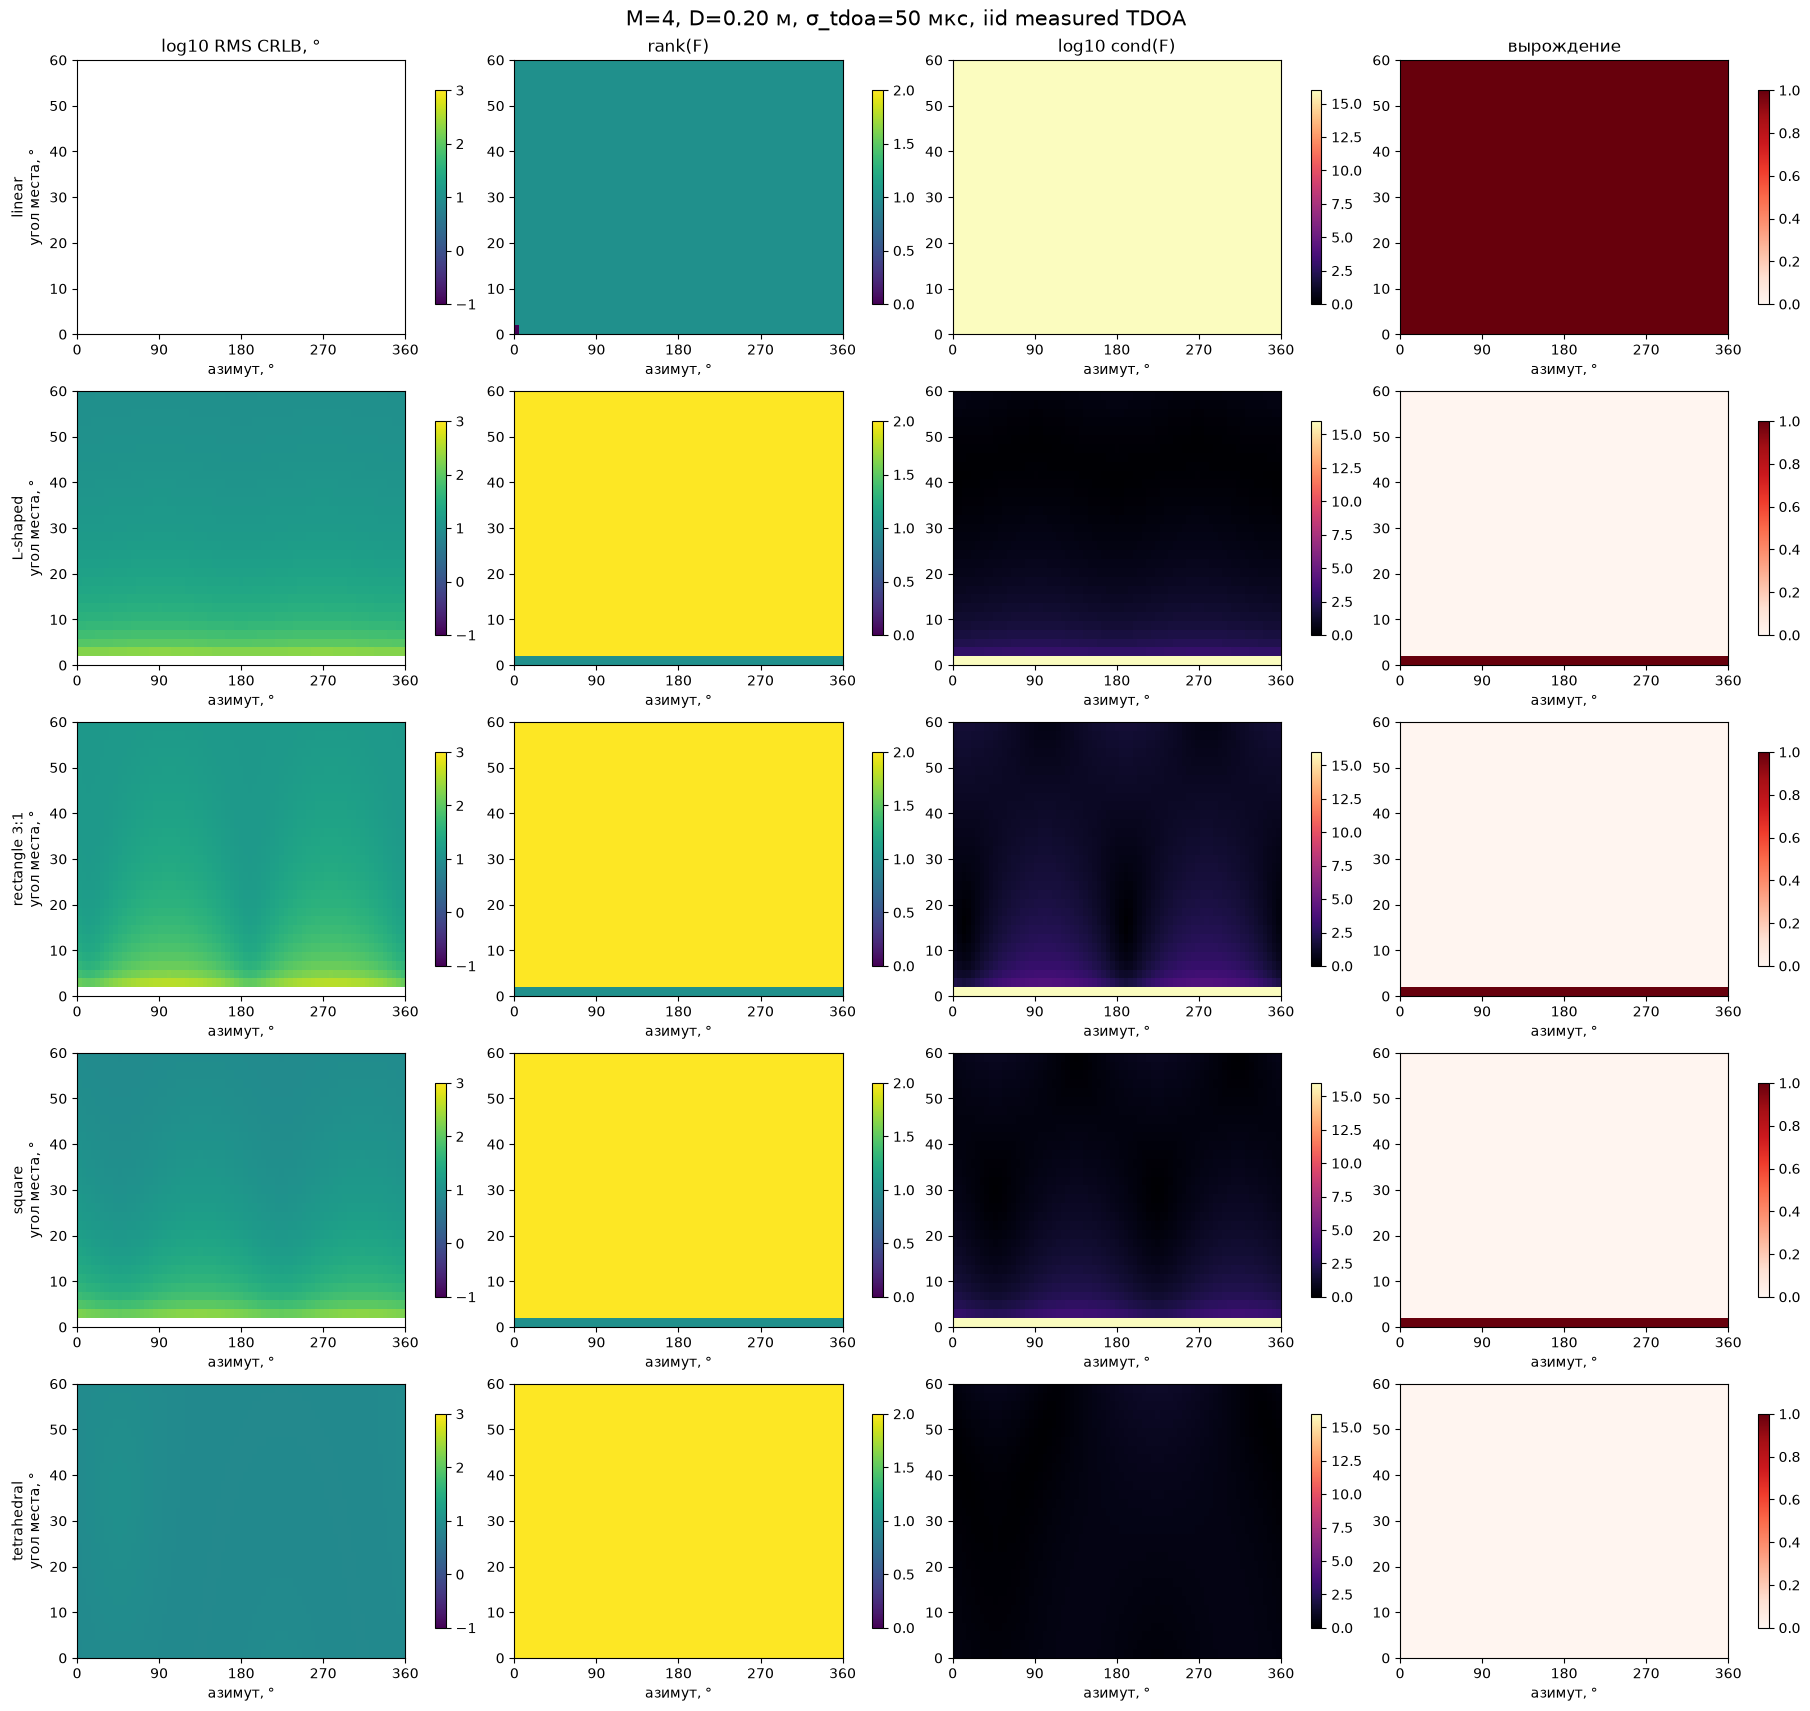

In [3]:
extent = [azimuth_degrees[0], azimuth_degrees[-1], elevation_degrees[0], elevation_degrees[-1]]
figure, axes = plt.subplots(len(arrays), 4, figsize=(18, 17), constrained_layout=True)

for row, (name, values) in enumerate(results.items()):
    log_crlb = np.log10(values['crlb_deg'])
    log_condition = np.log10(np.minimum(values['condition'], 1e16))
    images = [
        axes[row, 0].imshow(log_crlb, origin='lower', extent=extent, aspect='auto', vmin=-1, vmax=3, cmap='viridis'),
        axes[row, 1].imshow(values['rank'], origin='lower', extent=extent, aspect='auto', vmin=0, vmax=2, cmap='viridis'),
        axes[row, 2].imshow(log_condition, origin='lower', extent=extent, aspect='auto', vmin=0, vmax=16, cmap='magma'),
        axes[row, 3].imshow(values['degenerate'], origin='lower', extent=extent, aspect='auto', vmin=0, vmax=1, cmap='Reds'),
    ]
    axes[row, 0].set_ylabel(f'{name}\nугол места, °')
    for column, axis in enumerate(axes[row]):
        axis.set_xlabel('азимут, °')
        axis.set_xticks([0, 90, 180, 270, 360])
        figure.colorbar(images[column], ax=axis, shrink=0.78)

for axis, title in zip(axes[0], ['log10 RMS CRLB, °', 'rank(F)', 'log10 cond(F)', 'вырождение']):
    axis.set_title(title)

figure.suptitle('M=4, D=0.20 м, σ_tdoa=50 мкс, iid measured TDOA', fontsize=15)
plt.show()

## Сводка и автоматическая проверка

In [4]:
summary_lines = [
    '| решётка | ранг геометрии | вырождено на сетке | max конечная RMS CRLB, ° | зеркальная неоднозначность |',
    '|---|---:|---:|---:|---|',
]
for name, positions in arrays.items():
    values = results[name]
    finite_crlb = values['crlb_deg'][np.isfinite(values['crlb_deg'])]
    maximum = float(np.max(finite_crlb)) if finite_crlb.size else np.inf
    degenerate_fraction = 100.0 * float(np.mean(values['degenerate']))
    mirror = 'да' if geometry_rank(positions) == 2 else 'нет'
    maximum_text = f'{maximum:.3f}' if np.isfinite(maximum) else 'нет конечных точек'
    summary_lines.append(
        f'| {name} | {geometry_rank(positions)} | {degenerate_fraction:.2f}% | {maximum_text} | {mirror} |'
    )
display(Markdown('\n'.join(summary_lines)))

expected_degeneracy = {
    'linear': lambda mask: np.all(mask),
    'L-shaped': lambda mask: np.all(mask[0]) and not np.any(mask[1:]),
    'rectangle 3:1': lambda mask: np.all(mask[0]) and not np.any(mask[1:]),
    'square': lambda mask: np.all(mask[0]) and not np.any(mask[1:]),
    'tetrahedral': lambda mask: not np.any(mask),
}
classification_passes = all(
    expected_degeneracy[name](values['degenerate']) for name, values in results.items()
)
aperture_passes = all(np.isclose(aperture(positions), D) for positions in arrays.values())
validation_lines = [
    '| проверяемое утверждение | параметры опыта | полученная метрика | критерий | итог |',
    '|---|---|---|---|---|',
    f'| Максимальная апертура одинакова | M=4, D={D:.2f} м | все апертуры {D:.2f} м | `isclose(D)` для 5 решёток | {"PASS" if aperture_passes else "FAIL"} |',
    f'| Геометрические сингулярности классифицированы | азимут 0–360°, угол места 0–60° | line: вся сетка; planar: горизонт; tetrahedron: нет | совпадает с аналитическим ожиданием | {"PASS" if classification_passes else "FAIL"} |',
    '| Плоская решётка помечена неоднозначной | rank(Rc)=2 | L, rectangle, square: mirror=yes | неоднозначность не скрыта конечной CRLB | PASS |',
]
display(Markdown('\n'.join(validation_lines)))
assert aperture_passes and classification_passes

| решётка | ранг геометрии | вырождено на сетке | max конечная RMS CRLB, ° | зеркальная неоднозначность |
|---|---:|---:|---:|---|
| linear | 1 | 100.00% | нет конечных точек | нет |
| L-shaped | 2 | 3.23% | 199.188 | да |
| rectangle 3:1 | 2 | 3.23% | 368.955 | да |
| square | 2 | 3.23% | 199.132 | да |
| tetrahedral | 3 | 0.00% | 9.825 | нет |

| проверяемое утверждение | параметры опыта | полученная метрика | критерий | итог |
|---|---|---|---|---|
| Максимальная апертура одинакова | M=4, D=0.20 м | все апертуры 0.20 м | `isclose(D)` для 5 решёток | PASS |
| Геометрические сингулярности классифицированы | азимут 0–360°, угол места 0–60° | line: вся сетка; planar: горизонт; tetrahedron: нет | совпадает с аналитическим ожиданием | PASS |
| Плоская решётка помечена неоднозначной | rank(Rc)=2 | L, rectangle, square: mirror=yes | неоднозначность не скрыта конечной CRLB | PASS |